# Import libraries

In [5]:
# Changes to all modules will automatically be applied when any cell runs. 
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import pandas as pd
import numpy as np

import optuna

from pathlib import Path
import sys

sys.path.append(
    str(Path('..', 'utils_functionality', 'models'))
)

from modelling4_utils import (
    BetaVAEncoder,
)


VAE_params: {'latent_dim': 3, 'hidden_dim': 32, 'input_dim': 12, 'verbose': True}
Encoder: Sequential(
  (0): Linear(in_features=12, out_features=32, bias=True)
  (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.1, inplace=True)
)
Latent space:
	Mu: Linear(in_features=32, out_features=3, bias=True)
	log_sigma2: Linear(in_features=32, out_features=3, bias=True)
Decoder: Sequential(
  (0): Linear(in_features=3, out_features=32, bias=True)
  (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.1, inplace=True)
  (3): Linear(in_features=32, out_features=12, bias=True)
)


Epochs:   0%|          | 0/200 [00:00<?, ?it/s]

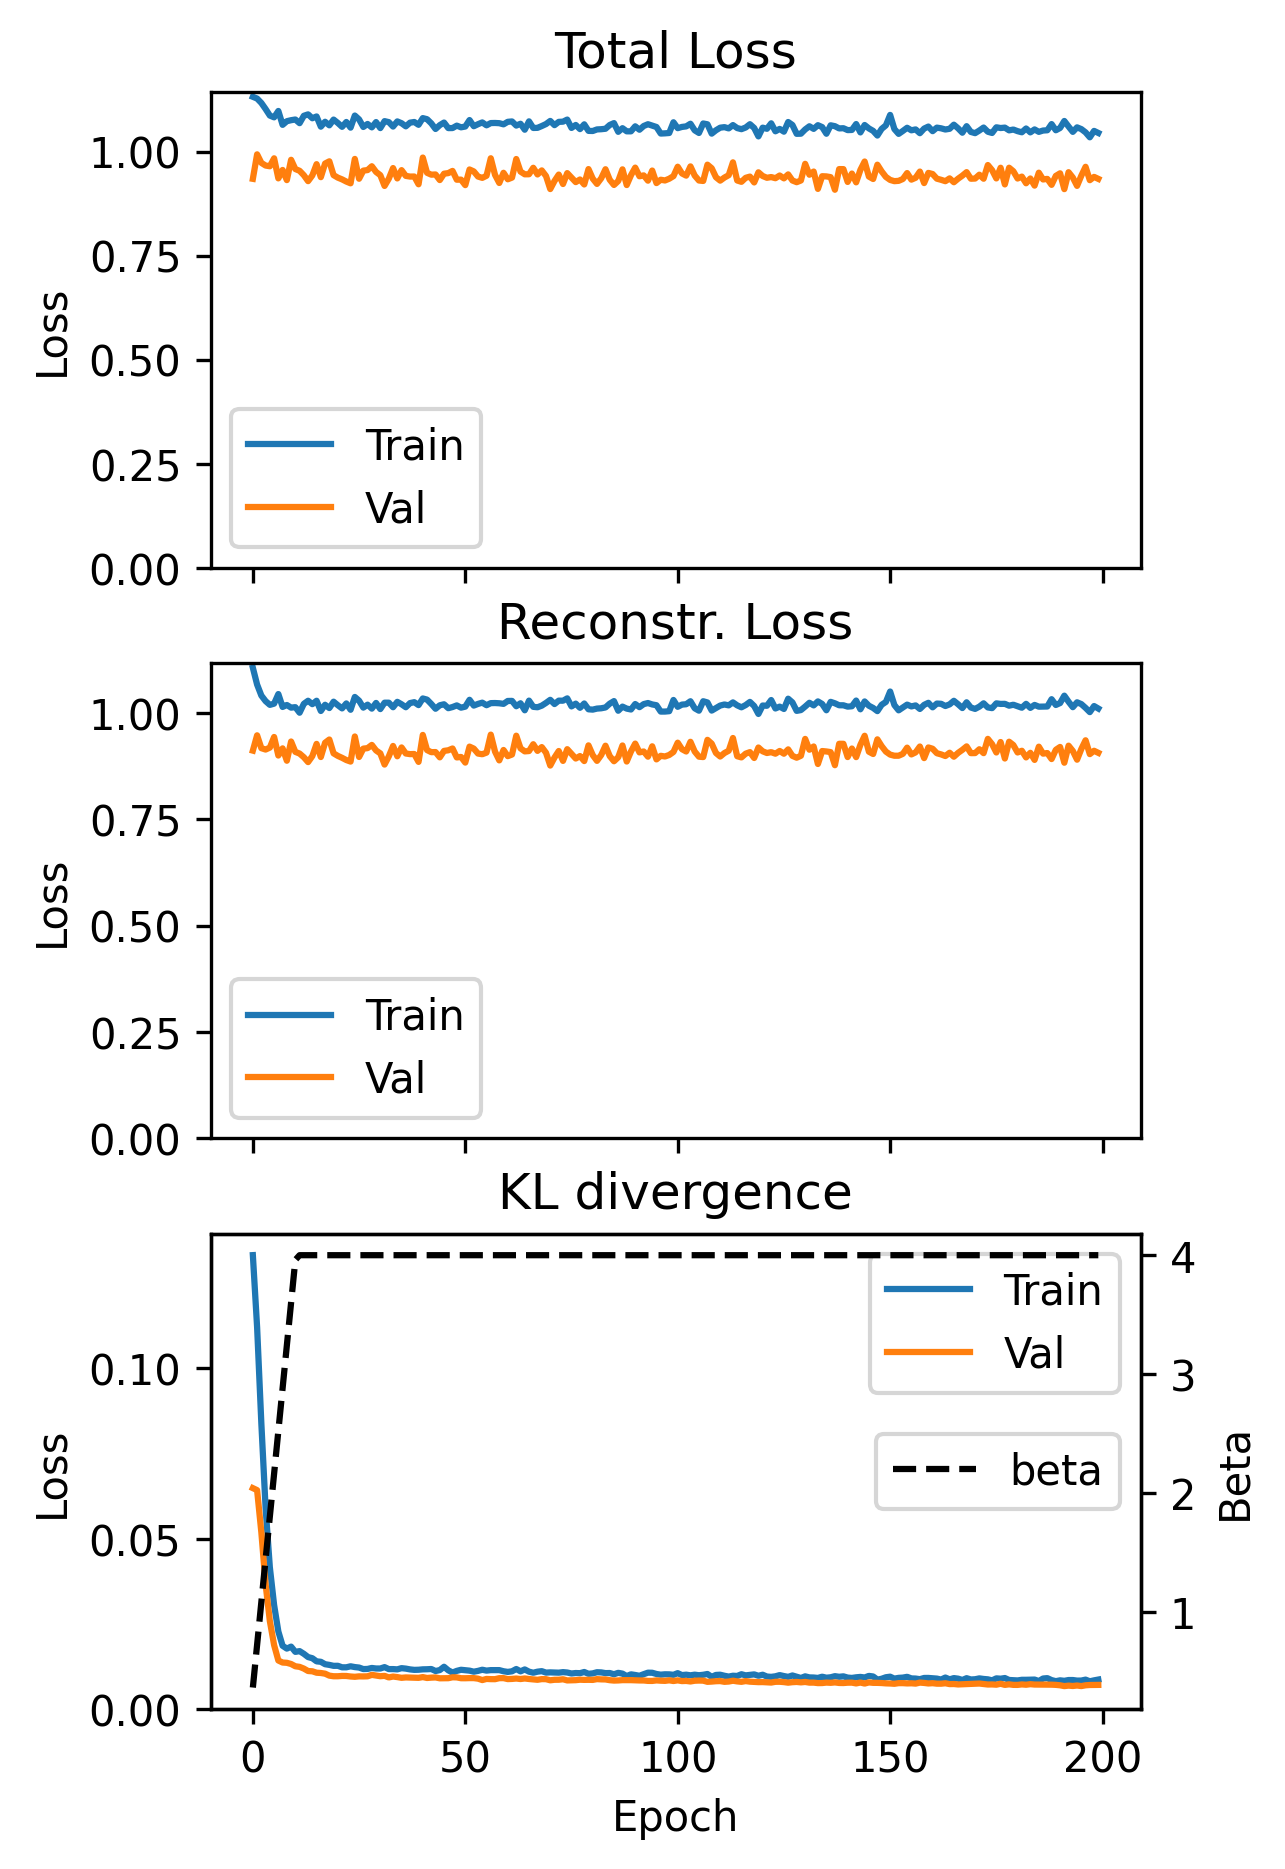

In [14]:
vae_encoder = BetaVAEncoder(
    VAE_params={
        'latent_dim': 3,
        'hidden_dim': 32,
    },
    verbose=True,
    learning_rate=1e-3,
    early_stopping=False,
    # scheduler_class=None,
    max_epochs=200,
)

X = np.random.randn(300, 12)

Z = vae_encoder.fit_transform(X)